## Q3: What is the financial cost of fraud, and how much does our model save?

We use Logistic Regression with PCA (Model 1) because its imperfect recall creates a meaningful before/after contrast — missed fraud cases have a real dollar cost that threshold tuning directly reduces.

**Approach:**
1. Same feature engineering and PCA pipeline as Model_PCA_LR.ipynb (C=1.0, 95% variance)
2. Apply two thresholds: default (0.5) and optimized (max recall @ precision ≥ 10%)
3. Translate TP, FP, FN into dollar values using actual transaction amounts
4. Compare net financial benefit before and after threshold tuning

**Cost assumptions:**
- **Missed fraud (FN):** Full transaction amount is lost
- **Caught fraud (TP):** Full transaction amount is saved
- **False alarm (FP):** $25 investigator review cost per flagged transaction

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix,
    average_precision_score,
    precision_recall_curve,
)
import warnings
warnings.filterwarnings('ignore')

INVESTIGATOR_COST = 25  # $ per false alarm reviewed

## 1. Load Data & Feature Engineering

Identical pipeline to Model_PCA_LR.ipynb.

In [ ]:
df = pd.read_csv('Financial_Fraud_dataset.csv')

df = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()
df['type_encoded']     = (df['type'] == 'TRANSFER').astype(int)
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']
df['origDrained']      = ((df['newbalanceOrig'] == 0) & (df['oldbalanceOrg'] > 0)).astype(int)
df['destUnchanged']    = (df['newbalanceDest'] == df['oldbalanceDest']).astype(int)
df['log_amount']       = np.log1p(df['amount'])

FEATURES = [
    'log_amount',
    'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest',
    'errorBalanceOrig', 'errorBalanceDest',
    'origDrained', 'destUnchanged',
    'type_encoded',
]

split_step = int(df['step'].quantile(0.80))
train_df   = df[df['step'] <= split_step]
test_df    = df[df['step'] >  split_step]

X_train = train_df[FEATURES].values
y_train = train_df['isFraud'].values
X_test  = test_df[FEATURES].values
y_test  = test_df['isFraud'].values

amounts_test = test_df['amount'].values

print(f"Test set: {len(y_test):,} transactions | Fraud: {y_test.sum():,} ({y_test.mean()*100:.4f}%)")
print(f"Total fraud value in test set: ${amounts_test[y_test == 1].sum():,.2f}")
print(f"Average fraud transaction:     ${amounts_test[y_test == 1].mean():,.2f}")

## 2. Train Logistic Regression Pipeline

StandardScaler → PCA (95% variance) → Logistic Regression with C=1.0.

In [ ]:
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_train), size=min(100_000, len(X_train)), replace=False)
X_sample = StandardScaler().fit_transform(X_train[sample_idx])
pca_full = PCA().fit(X_sample)
cumulative = np.cumsum(pca_full.explained_variance_ratio_)
N_COMPONENTS = int(np.argmax(cumulative >= 0.95)) + 1
print(f"PCA components for 95% variance: {N_COMPONENTS}")

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=N_COMPONENTS)),
    ('clf', LogisticRegression(
        C=1.0, class_weight='balanced', max_iter=1000, solver='lbfgs', random_state=42)),
])

print("Training pipeline...")
pipeline.fit(X_train, y_train)
y_proba = pipeline.predict_proba(X_test)[:, 1]
print(f"PR-AUC: {average_precision_score(y_test, y_proba):.4f}")

## 3. Define Thresholds

Three thresholds to compare:
- **Recall-priority:** maximize recall subject to precision ≥ 10%
- **F1-priority:** maximize F1 (balances precision and recall equally)

In [ ]:
precision_curve, recall_curve, thresholds = precision_recall_curve(y_test, y_proba)

# Recall-priority: maximize recall where precision >= 10%
PRECISION_FLOOR = 0.10
valid         = precision_curve[:-1] >= PRECISION_FLOOR
recall_thresh = thresholds[np.argmax(recall_curve[:-1] * valid)]

# F1-priority: maximize F1
f1_scores  = 2 * (precision_curve[:-1] * recall_curve[:-1]) / (precision_curve[:-1] + recall_curve[:-1] + 1e-9)
f1_thresh  = thresholds[np.argmax(f1_scores)]

y_pred_recall = (y_proba >= recall_thresh).astype(int)
y_pred_f1     = (y_proba >= f1_thresh).astype(int)

print(f"Recall-priority threshold: {recall_thresh:.4f}")
print(f"F1-priority threshold:     {f1_thresh:.4f}")

## 4. Financial Impact — Recall-Priority vs F1-Priority

For each threshold:
- **Money saved:** sum of actual transaction amounts for correctly caught fraud (TP)
- **Money lost:** sum of actual transaction amounts for missed fraud (FN)
- **Investigation cost:** number of false alarms × $25 per review
- **Net benefit:** money saved − investigation cost

In [ ]:
def financial_summary(y_true, y_pred, amounts, investigator_cost, label):
    tn, fp, fn, tp_count = confusion_matrix(y_true, y_pred).ravel()

    tp_mask = (y_true == 1) & (y_pred == 1)
    fn_mask = (y_true == 1) & (y_pred == 0)

    money_saved = amounts[tp_mask].sum()
    money_lost  = amounts[fn_mask].sum()
    invest_cost = fp * investigator_cost
    net_benefit = money_saved - invest_cost

    print(f"{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    print(f"  Fraud cases caught (TP):       {tp_count:,}")
    print(f"  Fraud cases missed (FN):       {fn:,}")
    print(f"  False alarms (FP):             {fp:,}")
    print(f"  Recall:    {tp_count / (tp_count + fn):.4f}")
    print(f"  Precision: {tp_count / (tp_count + fp):.4f}")
    print()
    print(f"  Money saved  (caught fraud):   ${money_saved:>15,.2f}")
    print(f"  Money lost   (missed fraud):   ${money_lost:>15,.2f}")
    print(f"  Investigation cost ($25/FP):  -${invest_cost:>15,.2f}")
    print(f"  {'─'*40}")
    print(f"  Net benefit:                   ${net_benefit:>15,.2f}")
    print()

    return {
        'label': label,
        'tp': tp_count, 'fn': fn, 'fp': fp,
        'money_saved': money_saved,
        'money_lost':  money_lost,
        'invest_cost': invest_cost,
        'net_benefit': net_benefit,
    }

results_recall = financial_summary(y_test, y_pred_recall, amounts_test, INVESTIGATOR_COST, f'Recall-Priority  (threshold={recall_thresh:.4f})')
results_f1     = financial_summary(y_test, y_pred_f1,     amounts_test, INVESTIGATOR_COST, f'F1-Priority      (threshold={f1_thresh:.4f})')

## 5. Side-by-Side Comparison Chart

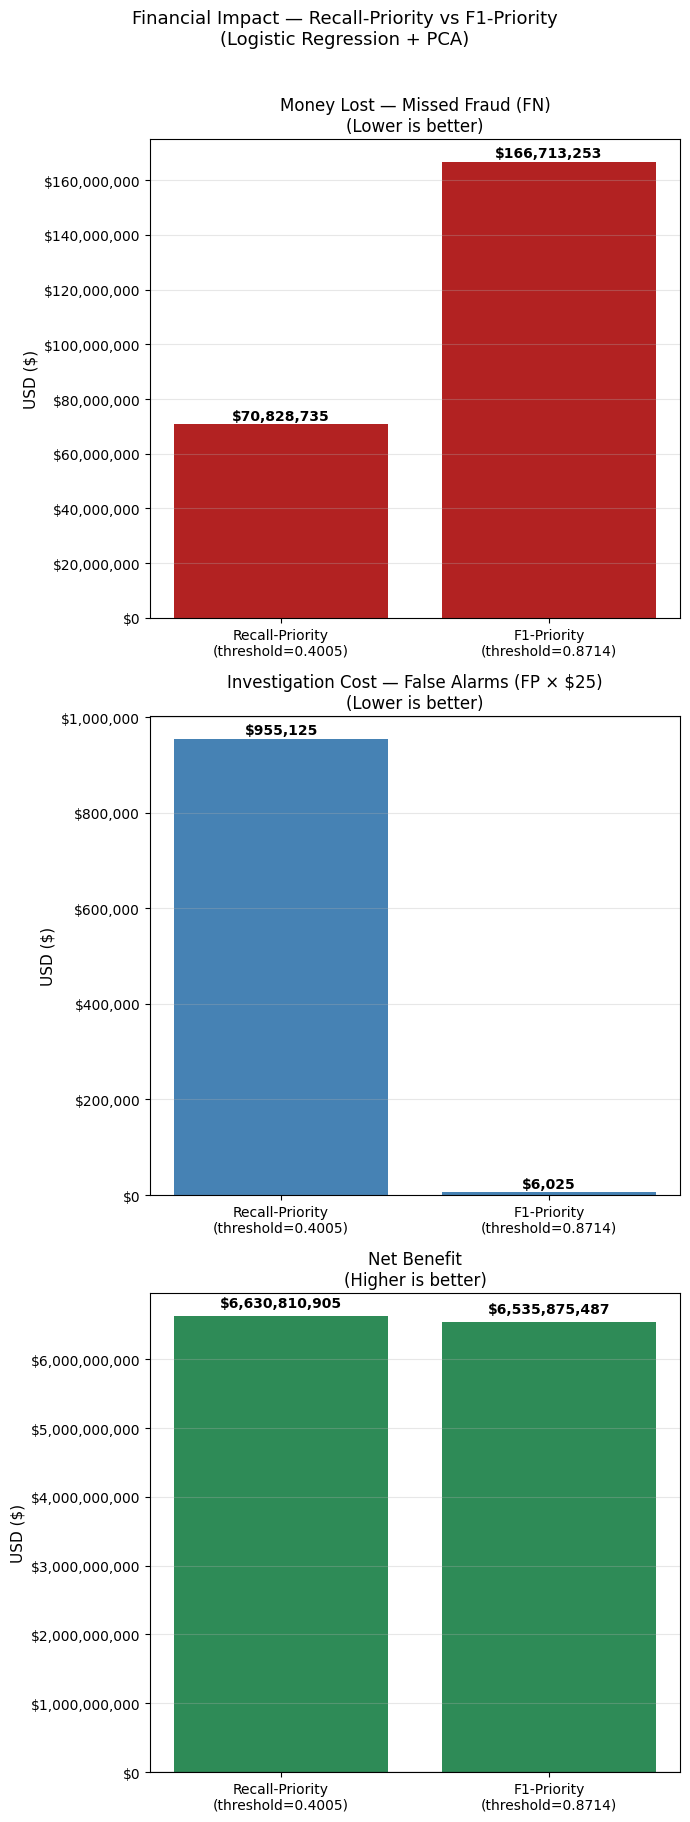

Net benefit difference: $94,935,418.01 in favour of Recall-Priority


In [ ]:
labels   = [f'Recall-Priority\n(threshold={recall_thresh:.4f})', f'F1-Priority\n(threshold={f1_thresh:.4f})']
lost     = [results_recall['money_lost'],   results_f1['money_lost']]
inv_cost = [results_recall['invest_cost'],  results_f1['invest_cost']]
net      = [results_recall['net_benefit'],  results_f1['net_benefit']]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(7, 18))

# Chart 1: Money lost from missed fraud (FN)
ax1.bar(labels, lost, color='tomato', width=0.8)
ax1.set_ylabel('USD ($)', fontsize=11)
ax1.set_title('Money Lost — Missed Fraud (FN)\n(Lower is better)', fontsize=12)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(lost):
    ax1.text(i, v + max(lost) * 0.01, f'${v:,.0f}', ha='center', fontsize=10, fontweight='bold')

# Chart 2: Investigation cost from false alarms (FP)
ax2.bar(labels, inv_cost, color='steelblue', width=0.8)
ax2.set_ylabel('USD ($)', fontsize=11)
ax2.set_title('Investigation Cost — False Alarms (FP × $25)\n(Lower is better)', fontsize=12)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax2.grid(axis='y', alpha=0.3)
for i, v in enumerate(inv_cost):
    ax2.text(i, v + max(inv_cost) * 0.01, f'${v:,.0f}', ha='center', fontsize=10, fontweight='bold')

# Chart 3: Net benefit
colors_net = ['seagreen' if v >= 0 else 'firebrick' for v in net]
ax3.bar(labels, net, color=colors_net, width=0.8)
ax3.set_ylabel('USD ($)', fontsize=11)
ax3.set_title('Net Benefit\n(Higher is better)', fontsize=12)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax3.axhline(y=0, color='black', linewidth=0.8)
ax3.grid(axis='y', alpha=0.3)
for i, v in enumerate(net):
    ax3.text(i, v + max(abs(n) for n in net) * 0.02, f'${v:,.0f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Financial Impact — Recall-Priority vs F1-Priority\n(Logistic Regression + PCA)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

diff = results_recall['net_benefit'] - results_f1['net_benefit']
winner = 'Recall-Priority' if diff > 0 else 'F1-Priority'
print(f"Net benefit difference: ${abs(diff):,.2f} in favour of {winner}")


## 6. Summary

| | Recall-Priority | F1-Priority |
|---|---|---|
| Fraud caught | — | — |
| Fraud missed | — | — |
| False alarms | — | — |
| Money saved | — | — |
| Money lost | — | — |
| Investigation cost | — | — |
| **Net benefit** | — | — |

*(Run all cells to populate)*

**Key takeaway:** F1 balances precision and recall equally, which minimizes false alarms but accepts more missed fraud. Recall-priority catches more fraud but generates more investigator cost. The net benefit comparison shows which strategy is financially justified given the $25/review assumption.

## 7. Financial Confusion Matrices

Each cell shows the dollar impact instead of a count:
- **TP:** money saved by catching fraud
- **FN:** money lost from missed fraud  
- **FP:** investigation cost (cases × $25)
- **TN:** $0 — correctly cleared, no cost

In [ ]:
def money_confusion_matrix(y_true, y_pred, amounts, investigator_cost, label, ax):
    tn, fp, fn, tp_count = confusion_matrix(y_true, y_pred).ravel()

    tp_mask = (y_true == 1) & (y_pred == 1)
    fn_mask = (y_true == 1) & (y_pred == 0)

    money_tp = amounts[tp_mask].sum()
    money_fn = amounts[fn_mask].sum()
    money_fp = fp * investigator_cost
    money_tn = 0.0

    # Build 2x2 dollar matrix: [[TN, FP], [FN, TP]]
    dollar_matrix = np.array([[money_tn, money_fp],
                               [money_fn, money_tp]])

    # Format labels for each cell
    cell_labels = np.array([
        [f'$0\n(TN)\n{tn:,} cases',             f'${money_fp:,.0f}\n(FP cost)\n{fp:,} false alarms'],
        [f'${money_fn:,.0f}\n(FN loss)\n{fn:,} missed', f'${money_tp:,.0f}\n(TP saved)\n{tp_count:,} caught'],
    ])

    # Use a diverging colormap: green for TP/TN, red for FP/FN
    colors = np.array([[0.85, 0.2, 0.2, 0.2],   # TN: light (neutral)
                        [0.0,  0.0, 0.0, 0.0]])   # placeholder

    sns.heatmap(
        dollar_matrix,
        annot=cell_labels,
        fmt='',
        cmap='RdYlGn',
        ax=ax,
        xticklabels=['Predicted Legit', 'Predicted Fraud'],
        yticklabels=['Actual Legit', 'Actual Fraud'],
        linewidths=1,
        linecolor='white',
        annot_kws={'size': 10},
    )
    ax.set_title(label, fontsize=12, pad=10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

money_confusion_matrix(y_test, y_pred_recall, amounts_test, INVESTIGATOR_COST,
                       f'Recall-Priority (thresh={recall_thresh:.4f})', axes[0])
money_confusion_matrix(y_test, y_pred_f1, amounts_test, INVESTIGATOR_COST,
                       f'F1-Priority (thresh={f1_thresh:.4f})', axes[1])

plt.suptitle('Financial Confusion Matrices — Dollar Impact per Cell', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
